<a href="https://colab.research.google.com/github/AvishManiar21/instacart-customer-behaviour/blob/main/Instacart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instacart — Customer Behaviour Analysis

Behavioural analysis of **3.2 million grocery orders** from **206,209 customers**:
what people reorder, how shopping habits form, and how quickly discovery gives
way to routine.

Instacart released this data in 2017 — anonymised, but real orders from real
customers. Unlike most public e-commerce datasets, **every customer here is a
repeat customer** (4–100 orders each, median 10), which is what makes
behavioural analysis possible.

| File | Rows | Grain |
|---|---:|---|
| `orders` | 3,421,083 | one row per order |
| `order_products__prior` | 32,434,489 | one row per **product per order** |
| `products` | 49,688 | one row per product |
| `aisles` | 134 | lookup |
| `departments` | 21 | lookup |

**What this data does not contain**

- **No dates** — only day-of-week, hour, and days-since-previous-order. No
  trends, seasonality or time series are possible.
- **No prices** — no revenue, order value or margin.

So this is a study of *behaviour*, not commerce.

## Setup

Downloads the dataset from Kaggle. Requires a `kaggle.json` API token
(kaggle.com → Settings → API → Create New Token), uploaded when prompted.

Roughly 680 MB — takes 1–2 minutes.

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
print("Upload kaggle.json  (kaggle.com → Settings → API → Create New Token)")
_ = files.upload()

Upload kaggle.json  (kaggle.com → Settings → API → Create New Token)


Saving kaggle.json to kaggle.json


In [4]:
import glob, os, shutil

os.makedirs('/root/.kaggle', exist_ok=True)
src = max(glob.glob('/content/kaggle*.json'), key=os.path.getmtime)  # newest upload
shutil.move(src, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("installed from:", src)

installed from: /content/kaggle.json


In [5]:
!kaggle datasets download -d psparks/instacart-market-basket-analysis -p /content/data --unzip
!ls -lh /content/data

Dataset URL: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
License(s): CC0-1.0
100% 197M/197M [00:01<00:00, 109MB/s]

total 681M
-rw-r--r-- 1 root root 2.6K Aug 15 02:27 aisles.csv
-rw-r--r-- 1 root root  270 Aug 15 02:27 departments.csv
-rw-r--r-- 1 root root 551M Aug 15 02:28 order_products__prior.csv
-rw-r--r-- 1 root root  24M Aug 15 02:28 order_products__train.csv
-rw-r--r-- 1 root root 104M Aug 15 02:28 orders.csv
-rw-r--r-- 1 root root 2.1M Aug 15 02:28 products.csv


## Load

Column dtypes are set explicitly rather than left to pandas' defaults. `int64`
on every numeric column would be wasteful on 3.4M rows, and `eval_set` as
`object` would store 3.4M separate strings where three categories will do.

In [6]:
import pandas as pd
import numpy as np
DATA = '/content/data'

orders = pd.read_csv(f'{DATA}/orders.csv',dtype = {
        'order_id': 'int32',
        'user_id': 'int32',
        'order_number': 'int16',
        'order_dow': 'int8',
        'order_hour_of_day': 'int8',
        'days_since_prior_order': 'float32',
        'eval_set': 'category',
        })

prior = pd.read_csv(f'{DATA}/order_products__prior.csv', dtype={
    'order_id':          'int32',
    'product_id':        'int32',
    'add_to_cart_order': 'int16',
    'reordered':         'int8',
    })

products    = pd.read_csv(f'{DATA}/products.csv')
aisles      = pd.read_csv(f'{DATA}/aisles.csv')
departments = pd.read_csv(f'{DATA}/departments.csv')

for name, df in [('orders', orders), ('prior', prior), ('products', products),
                 ('aisles', aisles), ('departments', departments)]:
    mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name:12} {len(df):>12,} rows   {mb:>7.1f} MB")


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 13





orders          3,421,083 rows      55.5 MB
prior          32,434,489 rows     340.3 MB
products           49,688 rows       4.9 MB
aisles                134 rows       0.0 MB
departments            21 rows       0.0 MB


> Typed load: **55.5 MB**. The default `int64`/`object` load is roughly 360 MB —
> about **6.5× larger** for identical data.

## Profiling: `orders`

One row per order. This is the spine of the dataset — everything else joins to it.

In [7]:
print(orders.head())
print(orders.shape)
orders.info(memory_usage = 'deep')


   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
(3421083, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int16   
 4   order_dow  

### Summary Statistics


In [8]:
orders.describe()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111483e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.161989e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


> **Observations**
>
> - `order_number` runs 1–100 — every user has between 1 and 100 orders
> - `order_dow` spans 0–6, `order_hour_of_day` spans 0–23 — complete ranges
> - `days_since_prior_order` maxes at exactly **30** — investigated below

### Missing Values


In [9]:
print(orders.isnull().sum().to_string())
print(f"\nusers in dataset: {orders.user_id.nunique():,}")

nulls = orders[orders.days_since_prior_order.isna()]
print(f"null rows       : {len(nulls):,}")
print(f"distinct users  : {nulls.user_id.nunique():,}")
print(f"all order #1?   : {(nulls.order_number == 1).all()}")

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209

users in dataset: 206,209
null rows       : 206,209
distinct users  : 206,209
all order #1?   : True


> **206,209 nulls = 206,209 users** — one each, all on `order_number == 1`.
>
> Structural, not missing: a first order has no prior order to measure from.
> These must not be imputed or dropped.

### Grain and Keys

In [10]:
print(f"rows              : {len(orders):,}")
print(f"unique order_id   : {orders.order_id.nunique():,}   <- primary key")
print(f"unique user_id    : {orders.user_id.nunique():,}\n")
print("orders per user:")
print(orders.groupby('user_id').size().describe().to_string())

rows              : 3,421,083
unique order_id   : 3,421,083   <- primary key
unique user_id    : 206,209

orders per user:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000


> `order_id` is unique — confirmed one row per order.
>
> Every user has **at least 4 orders** (median 10). Unlike most public
> e-commerce data, every customer here is a repeat customer — which is what
> makes behavioural analysis possible.

### The `eval_set` split

The data was released for a prediction competition, so orders are split three ways.


In [11]:
print(orders.eval_set.value_counts().to_string())
print(f"\nusers in each split:")
print(orders.groupby('eval_set').user_id.nunique().to_string())


eval_set
prior    3214874
train     131209
test       75000

users in each split:
eval_set
prior    206209
test      75000
train    131209


/tmp/ipykernel_896/1192589636.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(orders.groupby('eval_set').user_id.nunique().to_string())


> Orders split `prior` 3,214,874 / `train` 131,209 / `test` 75,000.
>
> All 206,209 users appear in `prior`. Which splits have product data is
> checked later, once the product files are loaded.

### Trap: `days_since_prior_order` is censored at 30

`describe()` showed this column maxing out at exactly 30 — a suspiciously round
number. Checking the distribution near the top of the range.


In [12]:
gap = orders['days_since_prior_order']

print("max gap:", gap.max())
print("orders at the max:", (gap == gap.max()).sum())
print("share of all orders:",round((gap == gap.max()).mean()*100,1))
print("Counts for the last 6 days:")
print(gap.value_counts().sort_index().tail(6).to_string())

max gap: 30.0
orders at the max: 369323
share of all orders: 10.8
Counts for the last 6 days:
days_since_prior_order
25.0     19234
26.0     19016
27.0     22013
28.0     26777
29.0     19191
30.0    369323


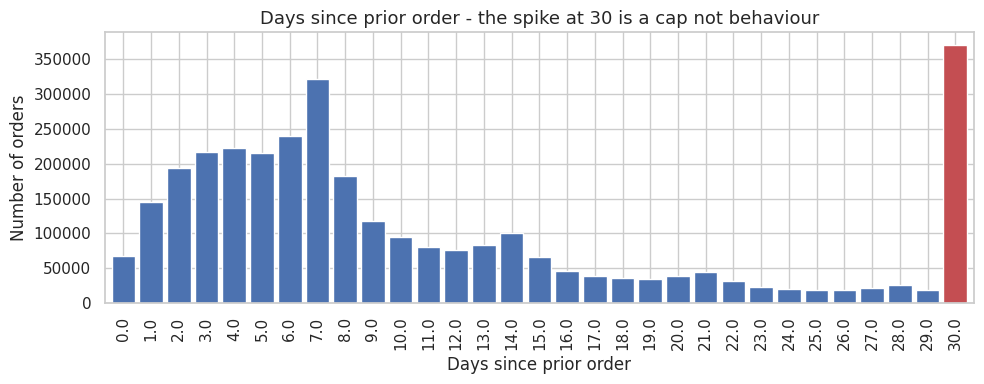

In [13]:
counts = gap.value_counts().sort_index()
colors = ['#C44E52' if d == 30 else '#4C72B0' for d in counts.index]
ax= counts.plot(kind='bar',color=colors,width=0.85)
ax.set_title("Days since prior order - the spike at 30 is a cap not behaviour")
ax.set_xlabel("Days since prior order")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

>Two things are visible here.
>
> **The cap:** day 30 holds 369,323 orders against ~17,000 on day 29. No value
> above 30 exists. A ceiling with a pile-up on it means `30` is really "30 or more".
>
> **A weekly rhythm:** days 7, 14 and 21 each sit above their neighbours, with
> day 7 at ~320,000 — nearly double day 6. Customers shop on the same day each
> week, and the echo fades as the habit gets less regular.

#### Recovering information from the censored column

The true gaps were destroyed before publication — but `order_dow` (day of week)
still encodes information about them.

If a gap were exactly 30 days, the day of week must shift by exactly
`30 mod 7 = 2`. Wherever it shifted by any other amount, the gap **cannot** have
been 30 — it must have been longer.

The method is validated first on the 2.8M orders where the true gap is known.


In [14]:
o = orders.sort_values(['user_id', 'order_number']).copy()
o['prev_dow'] = o.groupby('user_id')['order_dow'].shift(1)

# --- Step 1: validate where the answer is already known ----------------------
known = o[o.days_since_prior_order.between(1, 29) & o.prev_dow.notna()].copy()
known['dow_shift'] = (known.order_dow - known.prev_dow) % 7
known['expected']  = known.days_since_prior_order % 7
accuracy = (known.dow_shift == known.expected).mean()

print("VALIDATION — orders with a known gap (1-29 days)")
print(f"  rows checked : {len(known):,}")
print(f"  accuracy     : {accuracy*100:.2f}%\n")

# --- Step 2: apply to the censored rows --------------------------------------
capped = o[(o.days_since_prior_order == 30) & o.prev_dow.notna()].copy()
capped['dow_shift'] = (capped.order_dow - capped.prev_dow) % 7
could_be_30 = capped.dow_shift == (30 % 7)

print("CENSORED ROWS — recorded as 30")
print(f"  capped orders              : {len(capped):,}")
print(f"  consistent with exactly 30 : {could_be_30.sum():,}  ({could_be_30.mean()*100:.1f}%)")
print(f"  PROVABLY longer than 30    : {(~could_be_30).sum():,}  ({(~could_be_30).mean()*100:.1f}%)")

del o, known, capped

VALIDATION — orders with a known gap (1-29 days)
  rows checked : 2,777,796
  accuracy     : 100.00%

CENSORED ROWS — recorded as 30
  capped orders              : 369,323
  consistent with exactly 30 : 54,398  (14.7%)
  PROVABLY longer than 30    : 314,925  (85.3%)


> **314,925 orders (85.3%) are provably longer than 30 days.**
>
> The method validates at 100.00% across 2.8M orders with known gaps, so this is
> arithmetic rather than assumption.
>
> The 14.7% that *could* be exactly 30 is close to 1/7 (14.3%) — what you would
> expect if the true gaps were an arbitrary mix of lengths landing randomly
> across the seven possible day-of-week shifts. Two independent readings agreeing.
>
> **Consequence:** the mean gap (11.1 days) understates reality and is not
> quoted anywhere in this analysis. The median (7 days) sits far below the cap
> and is unaffected.

Given the cap, the column is banded for downstream use. The top band is labelled
`30+ days` rather than `30`, so no later chart or table implies a precision the
data does not have.


In [15]:
orders['gap_band'] = pd.cut(
    orders.days_since_prior_order,
    bins=[-1, 0, 3, 7, 14, 29, 30],
    labels=['same day', '1-3 days', '4-7 days', '8-14 days', '15-29 days', '30+ days']
)

print(orders.gap_band.value_counts().sort_index().to_string())
print(f"\nunbanded (first orders): {orders.gap_band.isna().sum():,}")

gap_band
same day       67755
1-3 days      555458
4-7 days      996820
8-14 days     735651
15-29 days    489867
30+ days      369323

unbanded (first orders): 206,209


### When do people shop?

Day and hour together — a heatmap shows whether the daily rhythm differs
between the two peak days and the rest of the week

In [16]:
dow  = orders.order_dow.value_counts().sort_index()
hour = orders.order_hour_of_day.value_counts().sort_index()

print("Orders by day of week:")
for d, n in dow.items():
    print(f"  day {d}: {n:>9,}  ({n/len(orders)*100:4.1f}%)")

print("\nOrders by hour — busiest 5:")
for h, n in hour.sort_values(ascending=False).head().items():
    print(f"  {h:02d}:00  {n:>9,}  ({n/len(orders)*100:4.1f}%)")

print(f"\nquietest hour: {hour.idxmin():02d}:00 ({hour.min():,} orders)")

print("\nMidday hours in sequence:")
print(hour.loc[9:16].to_string())

Orders by day of week:
  day 0:   600,905  (17.6%)
  day 1:   587,478  (17.2%)
  day 2:   467,260  (13.7%)
  day 3:   436,972  (12.8%)
  day 4:   426,339  (12.5%)
  day 5:   453,368  (13.3%)
  day 6:   448,761  (13.1%)

Orders by hour — busiest 5:
  10:00    288,418  ( 8.4%)
  11:00    284,728  ( 8.3%)
  15:00    283,639  ( 8.3%)
  14:00    283,042  ( 8.3%)
  13:00    277,999  ( 8.1%)

quietest hour: 03:00 (5,474 orders)

Midday hours in sequence:
order_hour_of_day
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553


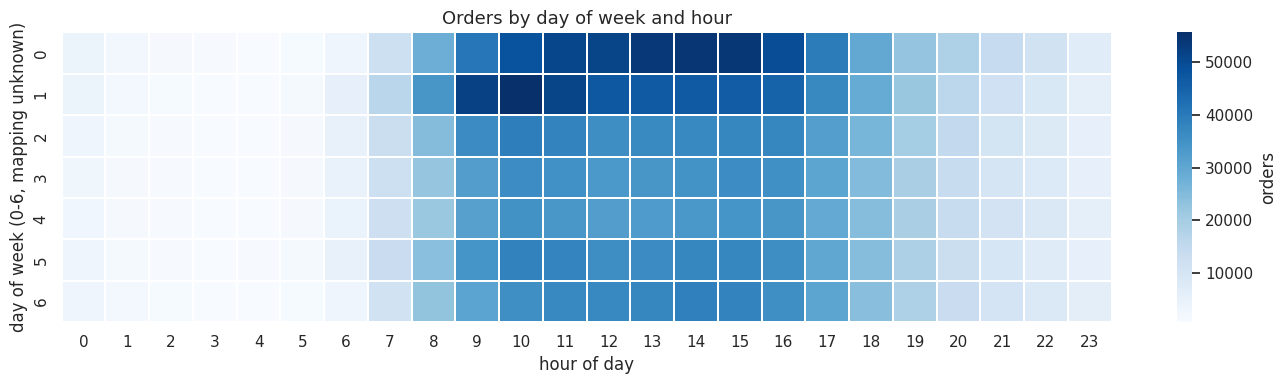

In [17]:
pivot =orders.pivot_table(index='order_dow', columns='order_hour_of_day',
                          values='order_id', aggfunc='count')
plt.figure(figsize=(14,4))
sns.heatmap(pivot,cmap='Blues',cbar_kws={'label':'orders'},linewidths=0.3,linecolor='white')
plt.title('Orders by day of week and hour')
plt.xlabel('hour of day')
plt.ylabel('day of week (0-6, mapping unknown)')
plt.tight_layout()
plt.show()

In [18]:
print("Peak hour for each day:")
for d in range(7):
    row = pivot.loc[d]
    print(f"  day {d}: peaks at {row.idxmax():02d}:00 ({row.max():,.0f} orders)")

Peak hour for each day:
  day 0: peaks at 14:00 (54,552 orders)
  day 1: peaks at 10:00 (55,671 orders)
  day 2: peaks at 10:00 (39,230 orders)
  day 3: peaks at 10:00 (36,040 orders)
  day 4: peaks at 10:00 (35,034 orders)
  day 5: peaks at 10:00 (38,313 orders)
  day 6: peaks at 14:00 (38,748 orders)


> **Volume:** days 0 and 1 carry 34.8% of orders between them, against
> 12.5–13.7% each for days 2–6.
>
> **Rhythm:** days 1–5 all peak at 10:00. Days 0 and 6 peak at 14:00 — and since
> the week wraps, those two are adjacent. A consecutive two-day block where
> people shop in the afternoon rather than the morning is a weekend signature,
> though the dataset provides no mapping to real weekday names so the days are
> left unnamed.
>
> The busiest single hour in the dataset is day 1 at 10:00 (55,671 orders).
>
> **All ordering happens between roughly 08:00 and 18:00** — hours 0–7 and 19–23
> are near-empty on every day.

## Profiling: `products`, `aisles`, `departments`

Three lookup tables. `products` carries foreign keys to both others, so they
collapse into a single readable product reference.

In [19]:
for name, df in [('products',products),('aisles',aisles),('departments',departments)]:
  print(name,':',len(df),'rows,',df.shape[1],'columns')
  print('columns:',list(df.columns))
print()
print(products.head())
print()
products.info()
print()
aisles.info()
print()
departments.info()


products : 49688 rows, 4 columns
columns: ['product_id', 'product_name', 'aisle_id', 'department_id']
aisles : 134 rows, 2 columns
columns: ['aisle_id', 'aisle']
departments : 21 rows, 2 columns
columns: ['department_id', 'department']

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------

> No nulls in any of the three. `products` carries the two foreign keys;
> `aisles` and `departments` are pure lookups.

### Keys


In [20]:
print('products    :', len(products), 'rows |', products.product_id.nunique(), 'unique product_id')
print('aisles      :', len(aisles), 'rows |', aisles.aisle_id.nunique(), 'unique aisle_id')
print('departments :', len(departments), 'rows |', departments.department_id.nunique(), 'unique department_id')
print()
print('aisle_id values used inside products      :', products.aisle_id.nunique())
print('department_id values used inside products :', products.department_id.nunique())

products    : 49688 rows | 49688 unique product_id
aisles      : 134 rows | 134 unique aisle_id
departments : 21 rows | 21 unique department_id

aisle_id values used inside products      : 134
department_id values used inside products : 21


> Rows equal unique values in all three tables, so `product_id`, `aisle_id` and
> `department_id` are each the primary key of their own table.
>
> Inside `products` they behave differently: `aisle_id` and `department_id` are
> **foreign keys**, mapping 49,688 products onto 134 aisles and 21 departments.
>
> All 134 aisles and all 21 departments are used, and every product resolves to
> a valid one — referential integrity holds both ways, so joins here are lossless.

### Combined product reference

In [21]:
prod = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
print(prod.shape)
print(prod.head())

(49688, 6)
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id                       aisle department  
0             19               cookies cakes     snacks  
1             13           spices seasonings     pantry  
2              7                         tea  beverages  
3              1                frozen meals     frozen  
4             13  marinades meat preparation     pantry  


> Row count stays at 49,688 through both joins — confirming neither key
> duplicated. Every product now carries a readable aisle and department.

### How products distribute across categories

In [22]:
print('products per department:')
print(prod.department.value_counts().to_string())

products per department:
department
personal care      6563
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
bakery             1516
deli               1322
missing            1258
international      1139
breakfast          1115
babies             1081
alcohol            1054
pets                972
meat seafood        907
other               548
bulk                 38


In [23]:
print('biggest aisles:')
print(prod.aisle.value_counts().head(10).to_string())
print()
print('smallest aisles:')
print(prod.aisle.value_counts().tail(5).to_string())

biggest aisles:
aisle
missing                 1258
candy chocolate         1246
ice cream ice           1091
vitamins supplements    1038
yogurt                  1026
chips pretzels           989
tea                      894
packaged cheese          891
frozen meals             880
cookies cakes            874

smallest aisles:
aisle
frozen juice                    47
baby accessories                44
packaged produce                32
bulk grains rice dried goods    26
bulk dried fruits vegetables    12


> The top five departments hold 26,570 of 49,688 products (53.5%); `bulk` has 38.
>
> Excluding the placeholder, the biggest aisles are candy chocolate (1,246),
> ice cream (1,091), vitamins (1,038), yogurt (1,026), chips (989) — nine of the
> top ten are **variety-heavy** categories where one product type spans many
> flavours and brands. Fresh produce, milk and meat are absent.
>
> Aisle size therefore measures **catalogue breadth, not purchase volume**.
> Whether the two relate is tested against `order_products__prior` below.
>
> Note also that the single largest "aisle" is `missing` (1,258) — examined next.

### The placeholder categories

`missing` and `other` appear at both aisle and department level. Checking whether
they cover the same products.

In [24]:
for label in ['missing', 'other']:
    a = prod.aisle == label
    d = prod.department == label
    print(label, '-> aisle:', a.sum(), '| department:', d.sum(),
          '| both:', (a & d).sum(), '| one but not other:', (a ^ d).sum())

missing -> aisle: 1258 | department: 1258 | both: 1258 | one but not other: 0
other -> aisle: 548 | department: 548 | both: 548 | one but not other: 0


> Perfect overlap, zero exceptions: no product is uncategorised at one level but
> not the other. Uncategorised products are therefore a single clean group of
> **1,806 (3.6% of the catalogue)**.

In [25]:
prod['is_categorised'] = ~prod.department.isin(['missing', 'other'])
print(prod.is_categorised.value_counts().to_string())

is_categorised
True     47882
False     1806


> Flagged rather than dropped, so later analysis can exclude them explicitly and
> report how many were excluded.